# Leaf Species Classification

Homework 3 - CS 451

Jackson Burke

jmburke4@crimson.ua.edu

In [66]:
# Imports

# A1
import pandas as pd
import matplotlib.pyplot as plt

# A2
import matplotlib.image as mpimg

# A3
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import random
from torch.utils.data import Dataset
from PIL import Image
import os
import json

## A1 - Dataset

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


train_csv:
              image                 label
0  images/18194.jpg    staphylea_trifolia
1  images/10203.jpg     crataegus_viridis
2   images/2123.jpg         larix_decidua
3  images/16168.jpg  magnolia_macrophylla
4  images/15577.jpg      castanea_dentata
Image Count: 14682, Class Count: 176

test_csv:
              image
0  images/15991.jpg
1  images/17362.jpg
2    images/641.jpg
3   images/2264.jpg
4  images/17255.jpg
Image Count: 3671



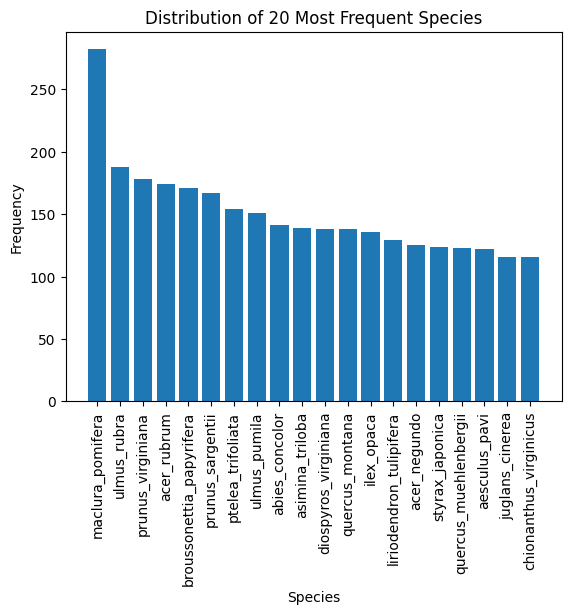

In [49]:
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3'

if not DATA_DIR or DATA_DIR == '':
  print('Please set the directory of your data directory')

train_csv = pd.read_csv(f'{DATA_DIR}/train.csv')
test_csv = pd.read_csv(f'{DATA_DIR}/test.csv')

print('train_csv:')
print(train_csv.head())
print(f'Image Count: {train_csv.shape[0]}, Class Count: {train_csv['label'].nunique()}')

print('\ntest_csv:')
print(test_csv.head())
print(f'Image Count: {test_csv.shape[0]}\n')

counts = train_csv['label'].value_counts().head(20)
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)

plt.title('Distribution of 20 Most Frequent Species')
plt.xlabel('Species')
plt.ylabel('Frequency')
plt.show()

## A2 - Visualization

In [50]:
# Specify how many random images to load
samples = train_csv.sample(n=12)

images = []
missing = 0

# Load and append images to the images list
for sample in samples.itertuples():
    # FIXME Only approximately 1000 images actually extracted to the google drive folder successfully
    #       Add a loop to keep picking random images until the sample size is reached
    try:
        print(f'Fetching {DATA_DIR}/{sample.image}...')
        img = mpimg.imread(f'{DATA_DIR}/{sample.image}')
        images.append(img)
    except FileNotFoundError as e:
        missing += 1
        print(f'Missing {DATA_DIR}/{sample.image}')

print(f'Done ({missing} images missing)')

Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/13153.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/11061.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/15841.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/6968.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/11314.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/570.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/5374.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/478.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/7124.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/15111.jpg...
Fetching /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/images/3219.jpg...
Fetching /content/drive/MyDrive/Colab No

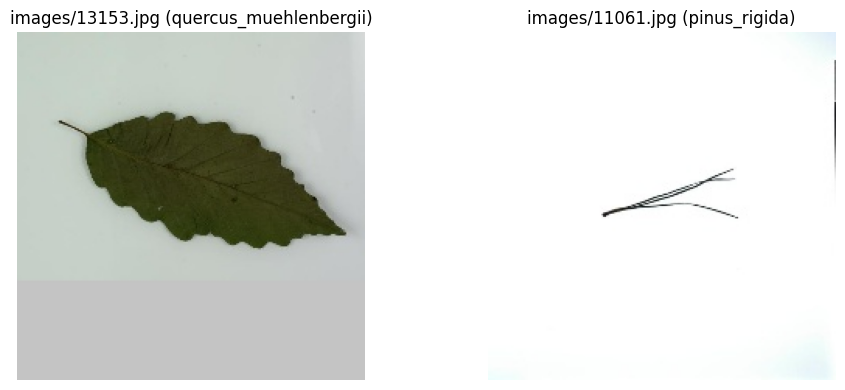

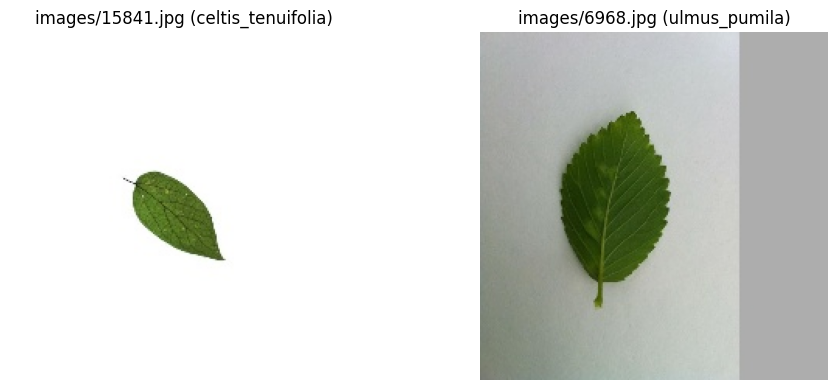

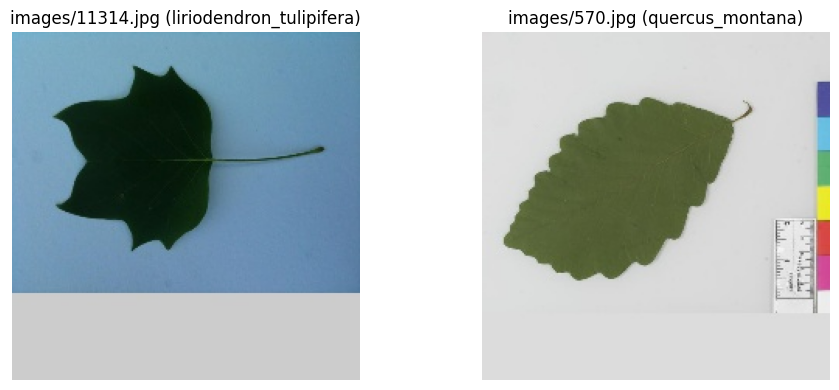

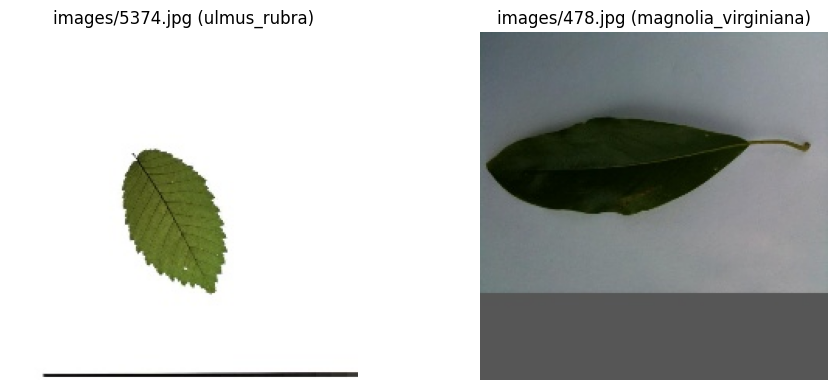

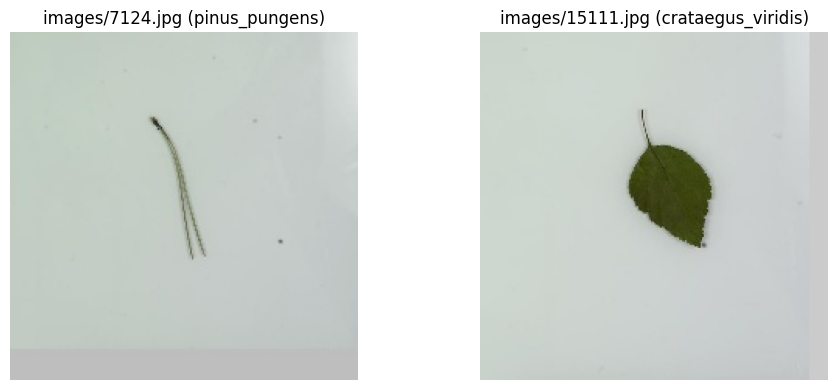

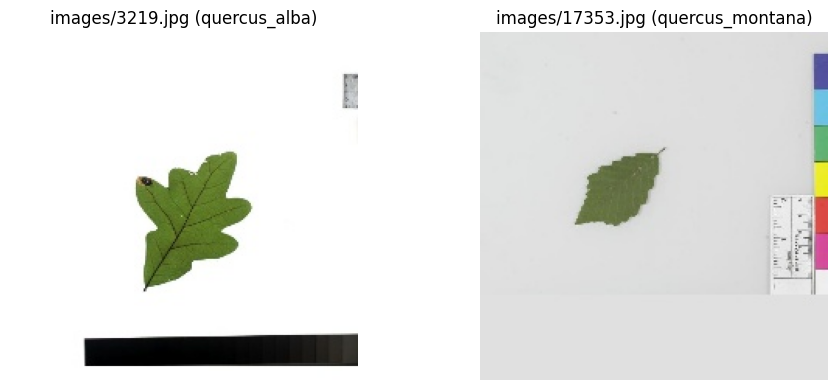

In [51]:
# Display the images 
for i in range(0, len(samples), 2):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    axs[0].imshow(images[i])
    axs[0].set_title(f'{samples.iloc[i]['image']} ({samples.iloc[i]['label']})')
    axs[0].axis('off')

    if i + 1 < len(samples):
        axs[1].imshow(images[i + 1])
        axs[1].set_title(f'{samples.iloc[i + 1]['image']} ({samples.iloc[i + 1]['label']})')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

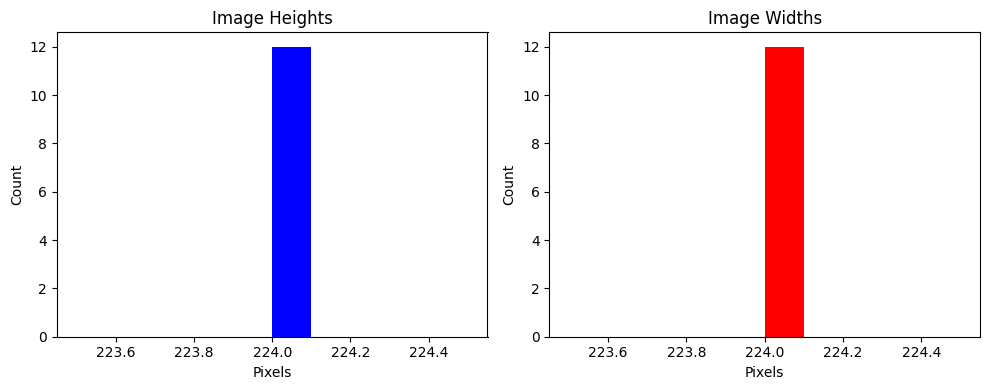

In [52]:
# shape returns (height, width, channel)

heights = []
widths = []
for i in range(len(images)):
    heights.append(images[i].shape[0])
    widths.append(images[i].shape[1])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

axes[0].hist(heights, color='blue')
axes[0].set_title('Image Heights')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Count')

axes[1].hist(widths, color='red')
axes[1].set_title('Image Widths')
axes[1].set_xlabel('Pixels')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## A3 - Model Training

In [ ]:
# ----------------------------
# Custom Dataset Class
# ----------------------------
class LeafDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None, is_test=False):
        self.df = pd.read_csv(csv_path)
        self.images_dir = images_dir
        self.transform = transform
        self.is_test = is_test
        
        # Get unique classes (only for training data)
        if not is_test and self.df.shape[1] > 1:
            self.classes = sorted(self.df.iloc[:, 1].unique())
            self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.images_dir, row.iloc[0])
        image = Image.open(image_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        if not self.is_test and self.df.shape[1] > 1:
            label = self.class_to_idx[row.iloc[1]]
            return image, label
        else:
            return image

# ----------------------------
# Configuration
# ----------------------------
BATCH_SIZE = 32
EPOCHS = 3
LR = 1e-3
SEED = 42
IMG_SIZE = 224

# ----------------------------
# Reproducibility
# ----------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ----------------------------
# Device
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ----------------------------
# Transforms (IMPORTANT: reuse in predict.py)
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean
        std=[0.229, 0.224, 0.225]     # ImageNet std
    )
])

# ----------------------------
# Dataset & fixed split (80/20)
# ----------------------------
train_csv_path = f'{DATA_DIR}/train.csv'
images_dir = f'{DATA_DIR}'

# Create dataset
full_dataset = LeafDataset(train_csv_path, images_dir, transform=transform, is_test=False)
num_classes = len(full_dataset.classes)

print(f'Dataset size: {len(full_dataset)}')
print(f'Number of classes: {num_classes}')
print(f'Classes: {full_dataset.classes}')
print()

label_map = {str(i): name for i, name in enumerate(full_dataset.classes)}
with open('label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# Model: Pretrained ResNet18
# ----------------------------
model = models.resnet18(pretrained=True)

# Replace final classifier
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ----------------------------
# Loss & Optimizer
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


Dataset size: 14682
Number of classes: 176
Classes: ['abies_concolor', 'abies_nordmanniana', 'acer_campestre', 'acer_ginnala', 'acer_griseum', 'acer_negundo', 'acer_palmatum', 'acer_pensylvanicum', 'acer_platanoides', 'acer_pseudoplatanus', 'acer_rubrum', 'acer_saccharinum', 'acer_saccharum', 'aesculus_flava', 'aesculus_glabra', 'aesculus_hippocastamon', 'aesculus_pavi', 'ailanthus_altissima', 'albizia_julibrissin', 'amelanchier_arborea', 'amelanchier_canadensis', 'amelanchier_laevis', 'asimina_triloba', 'betula_alleghaniensis', 'betula_jacqemontii', 'betula_lenta', 'betula_nigra', 'betula_populifolia', 'broussonettia_papyrifera', 'carpinus_betulus', 'carpinus_caroliniana', 'carya_cordiformis', 'carya_glabra', 'carya_ovata', 'carya_tomentosa', 'castanea_dentata', 'catalpa_bignonioides', 'catalpa_speciosa', 'cedrus_atlantica', 'cedrus_deodara', 'cedrus_libani', 'celtis_occidentalis', 'celtis_tenuifolia', 'cercidiphyllum_japonicum', 'cercis_canadensis', 'chamaecyparis_pisifera', 'chamaec

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [55]:
# ----------------------------
# Training loop
# ----------------------------
def accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_acc = accuracy(train_loader)
    val_acc = accuracy(val_loader)

    print(
        f'Epoch [{epoch+1}/{EPOCHS}] | '
        f'Loss: {running_loss:.4f} | '
        f'Train Acc: {train_acc:.4f} | '
        f'Val Acc: {val_acc:.4f}'
    )

# ----------------------------
# Save model
# ----------------------------
torch.save(model.state_dict(), f'{DATA_DIR}/model.pth')
print(f'Saved model to {DATA_DIR}/model.pth')

Epoch [1/3] | Loss: 969.5245 | Train Acc: 0.4533 | Val Acc: 0.4138
Epoch [2/3] | Loss: 468.1978 | Train Acc: 0.7010 | Val Acc: 0.6223
Epoch [3/3] | Loss: 308.1215 | Train Acc: 0.7725 | Val Acc: 0.6689
Saved model to /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/model.pth


In [56]:
# ----------------------------
# Load Test Dataset
# ----------------------------
test_csv_path = f'{DATA_DIR}/test.csv'
test_dataset = LeafDataset(test_csv_path, images_dir, transform=transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Test dataset size: {len(test_dataset)}')

Test dataset size: 3671


In [59]:
!python predict.py --data-dir "/content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3" --model-path "/content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/model.pth" --output submission.csv

Data directory: /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3
Model path: /content/drive/MyDrive/Colab Notebooks/Uploads/dataset_hw3/model.pth
Wrote predictions: /content/submission.csv (3671 rows)


## A4 - Results

Final validation accuracy: 0.6689
Validation samples: 2936
Misclassified samples: 972


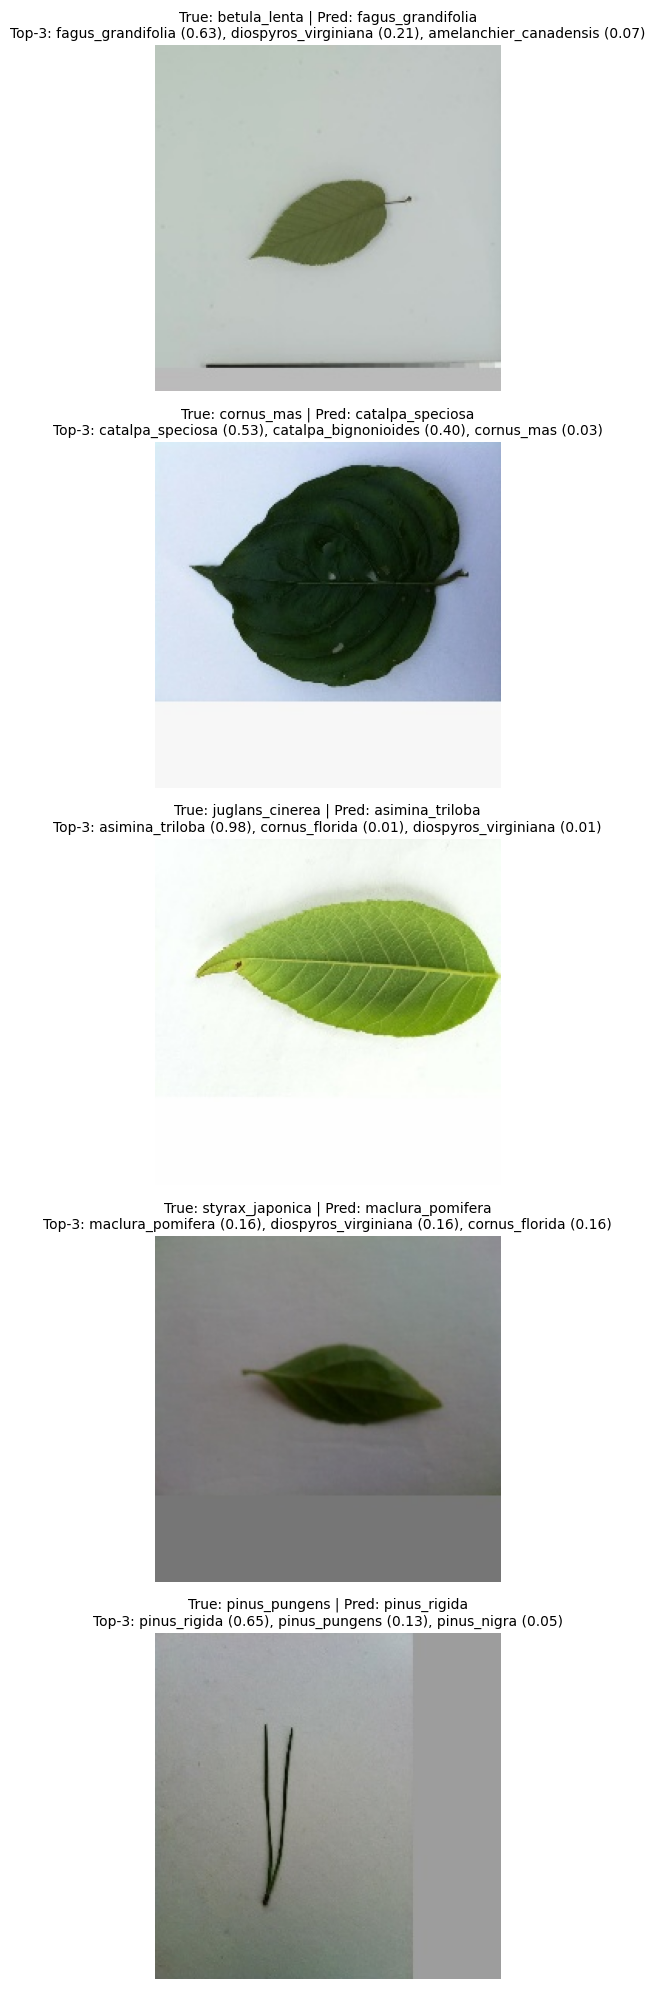

In [60]:
# ----------------------------
# A4 - Validation results and error analysis
# ----------------------------
model.eval()
idx_to_class = {idx: cls_name for cls_name, idx in full_dataset.class_to_idx.items()}

correct, total = 0, 0
misclassified = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(val_loader):
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        top3_probs, top3_idx = probs.topk(3, dim=1)
        mismatch_positions = torch.where(preds != labels)[0].tolist()

        for j in mismatch_positions:
            subset_idx = batch_idx * val_loader.batch_size + j
            original_idx = val_dataset.indices[subset_idx]
            image_rel_path = full_dataset.df.iloc[original_idx, 0]

            true_idx = labels[j].item()
            pred_idx = preds[j].item()

            misclassified.append(
                {
                    "image": image_rel_path,
                    "true": idx_to_class[true_idx],
                    "pred": idx_to_class[pred_idx],
                    "top3": [idx_to_class[k] for k in top3_idx[j].cpu().tolist()],
                    "top3_prob": [float(p) for p in top3_probs[j].cpu().tolist()],
                }
            )

val_accuracy = correct / total
print(f"Final validation accuracy: {val_accuracy:.4f}")
print(f"Validation samples: {total}")
print(f"Misclassified samples: {len(misclassified)}")

show_n = min(5, len(misclassified))
if show_n == 0:
    print("No misclassified validation images found.")
else:
    fig, axes = plt.subplots(show_n, 1, figsize=(10, 4 * show_n))
    if show_n == 1:
        axes = [axes]

    for ax, item in zip(axes, misclassified[:show_n]):
        img_path = os.path.join(images_dir, item["image"])
        img = Image.open(img_path).convert("RGB")
        top3_text = ", ".join(
            [f"{name} ({prob:.2f})" for name, prob in zip(item["top3"], item["top3_prob"])]
        )

        ax.imshow(img)
        ax.set_title(
            f"True: {item['true']} | Pred: {item['pred']}\nTop-3: {top3_text}",
            fontsize=10,
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Brief Discussion: Likely Failure Modes

- **Pose and viewpoint changes:** Leaves photographed at unusual angles or folded/curled shapes can differ from the common training appearance.
- **Lighting and color shifts:** Strong shadows, highlights, or color casts can reduce reliability because many species differ by subtle texture/color cues.
- **Background clutter:** Busy backgrounds or partial occlusion can distract the model from the leaf boundary and venation patterns.
- **Inter-class similarity:** Closely related species with similar shapes and margins are likely to be confused, especially when image resolution is limited.
- **Scale and crop variation:** Very zoomed-in or zoomed-out crops may hide key diagnostic features (serration, vein structure, petiole).